# House Price Prediction using Linear, Ridge and Lasso Regression

## Objective
Predict house prices using the Boston Housing dataset and compare:

- Linear Regression
- Ridge Regression
- Lasso Regression

Evaluation Metrics:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)

Visualizations:
- Residual Plot
- Coefficient Comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

 # Boston Housing Dataset Description

The Boston Housing Dataset contains information about houses and neighborhoods in different areas of Boston. It is commonly used for regression tasks to predict house prices.

## Target Variable

### MEDV (Median Value of Owner-Occupied Homes)
The median value of owner-occupied homes in a neighborhood, measured in thousands of dollars. This is the target variable that the model aims to predict.

## Feature Description

### CRIM
Per capita crime rate by town. Higher values indicate areas with higher crime rates.

### ZN
Proportion of residential land zoned for lots over 25,000 square feet. Higher values indicate larger residential plots.

### INDUS
Proportion of non-retail business acres per town. It represents the level of industrialization in the area.

### CHAS
Charles River dummy variable.
- 1 = Tract bounds the Charles River
- 0 = Otherwise

### NOX
Nitric oxide concentration (parts per 10 million). Higher values indicate greater air pollution.

### RM
Average number of rooms per dwelling. Houses with more rooms generally have higher market values.

### AGE
Proportion of owner-occupied units built before 1940. Higher values indicate older housing stock.

### DIS
Weighted distance to five Boston employment centers. Higher values mean the houses are located farther from major workplaces.

### RAD
Index of accessibility to radial highways. Higher values indicate better highway access.

### TAX
Full-value property tax rate per $10,000 of property value. Higher values indicate higher taxes.

### PTRATIO
Pupil-teacher ratio by town. It measures the average number of students per teacher in local schools.

### B
Calculated as:

B = 1000(Bk − 0.63)²

where Bk is the proportion of Black residents in the town. This feature represents demographic information.

### LSTAT
Percentage of the population with lower socioeconomic status. Higher values are generally associated with lower house prices.

## Summary

The dataset contains:

- *506 observations (rows)*
- *13 input features*
- *1 target variable (MEDV)*

The dataset is widely used for:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Feature Importance Analysis
- Regression Performance Evaluation using MAE, MSE, RMSE, and R² Score

In [2]:
columns = [
    "CRIM",      # Crime Rate
    "ZN",        # Residential Land
    "INDUS",     # Industrial Area
    "CHAS",      # Near River (0/1)
    "NOX",       # Nitric Oxide Level
    "RM",        # Average Rooms
    "AGE",       # Age of Houses
    "DIS",       # Distance to Employment Centers
    "RAD",       # Road Accessibility
    "TAX",       # Property Tax
    "PTRATIO",   # Pupil-Teacher Ratio
    "B",         # Population Factor
    "LSTAT",     # Lower Status Population %
    "MEDV"       # House Price (Target)
]


In [3]:
df = pd.read_csv(
    "housing.csv", names=columns, header=None,  delim_whitespace=True)

C:\Users\amara\AppData\Local\Temp\ipykernel_17608\3760183504.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


## Data Cleaning

Steps:
- Removed @DATA row
- Converted all columns to numeric
- Checked for missing values
- Checked for duplicate records

In [4]:
print("First 5 Rows:")
print(df.head())


First 5 Rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [5]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [7]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [8]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [9]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-1. , 0.7 , 0.28,...,-2.04, 1.13,-3.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[49.35,24.47,22.66,..., 8.51, 8.24, 5.07]"


In [12]:
y_pred = model.predict(X_test)

In [13]:
#Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print("\nMSE:", mse)


MSE: 24.291119474973517


In [14]:
#Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3.1890919658878483


In [15]:
#Residual Plot
residuals = y_test - y_pred

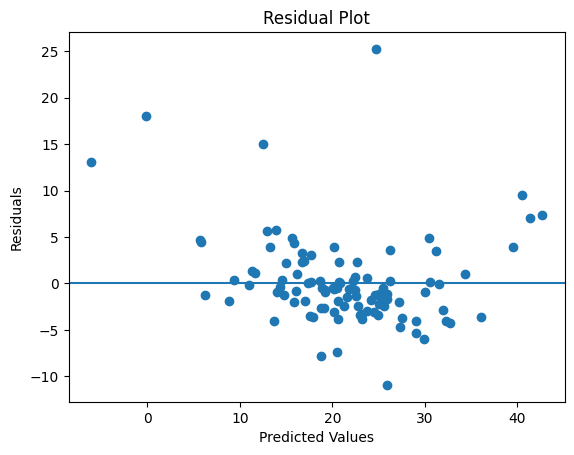

In [16]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Ridge Regression

Ridge Regression adds L2 regularization.

It reduces overfitting by shrinking coefficients.

In [17]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print("\nRidge MSE:", ridge_mse)



Ridge MSE: 24.31290383049162


## Lasso Regression

Lasso Regression adds L1 regularization.

It can reduce some coefficients to exactly zero,
performing automatic feature selection.

In [18]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)
print("Lasso MSE:", lasso_mse)

Lasso MSE: 25.65673936716768


In [19]:

# Compare Coefficients
print("\nLinear Regression Coefficients:")
print(model.coef_)
print("\nRidge Coefficients:")
print(ridge.coef_)
print("\nLasso Coefficients:")
print(lasso.coef_)


Linear Regression Coefficients:
[-1.00213533  0.69626862  0.27806485  0.7187384  -2.0223194   3.14523956
 -0.17604788 -3.0819076   2.25140666 -1.76701378 -2.03775151  1.12956831
 -3.61165842]

Ridge Coefficients:
[-0.99218679  0.6777488   0.2522143   0.72248078 -1.99083465  3.15157218
 -0.17726162 -3.04502895  2.17324941 -1.69555879 -2.02783351  1.127197
 -3.59897667]

Lasso Coefficients:
[-0.71836455  0.25962714 -0.          0.69822096 -1.56814243  3.27150693
 -0.         -2.28444944  0.67193802 -0.3566537  -1.89333519  1.03136581
 -3.60941047]


# Conclusion

- Linear Regression achieved baseline performance.
- Ridge Regression reduced coefficient magnitudes and improved stability.
- Lasso Regression performed feature selection by shrinking some coefficients toward zero.
- MSE and MAE were used to compare model performance.
- Regularization helps reduce overfitting and improves generalization.